In [229]:
! pip install xgboost scikit-learn scikit-optimize matplotlib seaborn pandas numpy joblib tqdm imblearn

In [230]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


warnings.filterwarnings('ignore')

## Import Data

In [231]:
clinical_data = pd.read_csv('/media/shadab/Others/cirrhosis+patient+survival+prediction+dataset-1/clinical_data_processed.csv')

In [232]:
clinical_data.head(50)

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Ascites_missing,Hepatomegaly_missing,Spiders_missing
0,16.027556,3,1,124.941528,1,2,2,2,3,103.014440,...,52.794521,21.950609,52.539568,49.957522,51.842315,4.2,4.0,0,0,0
1,187.651451,1,1,116.094531,1,1,2,2,1,6.747292,...,18.037671,105.178334,41.257206,20.371681,64.155689,2.6,3.0,0,0,0
2,41.645562,3,1,168.079782,2,1,1,1,2,8.902527,...,71.195205,4.328053,33.212230,8.748673,36.351297,4.0,4.0,0,0,0
3,79.863273,3,1,109.587235,1,1,2,2,2,11.776173,...,21.445205,86.514845,16.831330,21.780531,49.061876,2.3,4.0,0,0,0
4,62.240429,2,3,46.122822,1,1,2,2,1,23.270758,...,48.364726,6.600513,41.086331,14.736283,30.393214,2.9,3.0,0,0,0
5,104.058056,3,3,153.529761,1,1,2,1,1,4.592058,...,16.674658,10.602973,31.780576,11.566372,71.702595,3.0,3.0,0,0,0
6,75.970341,1,3,112.616313,1,1,2,1,1,6.028881,...,17.356164,8.843650,16.748201,64.398230,57.403194,1.7,3.0,0,0,0
7,102.509255,3,3,103.163500,1,1,1,1,1,1.000000,...,17.356164,64.954337,1.937503,55.945133,124.530938,3.0,3.0,0,0,0
8,99.746529,3,1,62.918539,1,1,1,2,1,21.833935,...,26.556507,30.131463,55.402878,20.371681,76.071856,3.0,2.0,0,0,0
9,1.418595,3,3,169.939009,1,2,1,2,3,89.364621,...,47.342466,10.221787,56.834532,39.743363,96.329341,3.5,4.0,0,0,0


In [233]:
# print the data types of each column
print(clinical_data.dtypes)

N_Days                  float64
Status                    int64
Drug                      int64
Age                     float64
Sex                       int64
Ascites                   int64
Hepatomegaly              int64
Spiders                   int64
Edema                     int64
Bilirubin               float64
Cholesterol             float64
Albumin                 float64
Copper                  float64
Alk_Phos                float64
SGOT                    float64
Tryglicerides           float64
Platelets               float64
Prothrombin             float64
Stage                   float64
Ascites_missing           int64
Hepatomegaly_missing      int64
Spiders_missing           int64
dtype: object


## Data Exploration

In [234]:
# Check data shape and basic info
print(f"Dataset shape: {clinical_data.shape}")
print(f"\nMissing values:\n{clinical_data.isnull().sum()}")
print(f"\nClass distribution:\n{clinical_data['Stage'].value_counts().sort_index()}")

Dataset shape: (412, 22)

Missing values:
N_Days                  0
Status                  0
Drug                    0
Age                     0
Sex                     0
Ascites                 0
Hepatomegaly            0
Spiders                 0
Edema                   0
Bilirubin               0
Cholesterol             0
Albumin                 0
Copper                  0
Alk_Phos                0
SGOT                    0
Tryglicerides           0
Platelets               0
Prothrombin             0
Stage                   0
Ascites_missing         0
Hepatomegaly_missing    0
Spiders_missing         0
dtype: int64

Class distribution:
Stage
1.0     21
2.0     92
3.0    155
4.0    144
Name: count, dtype: int64


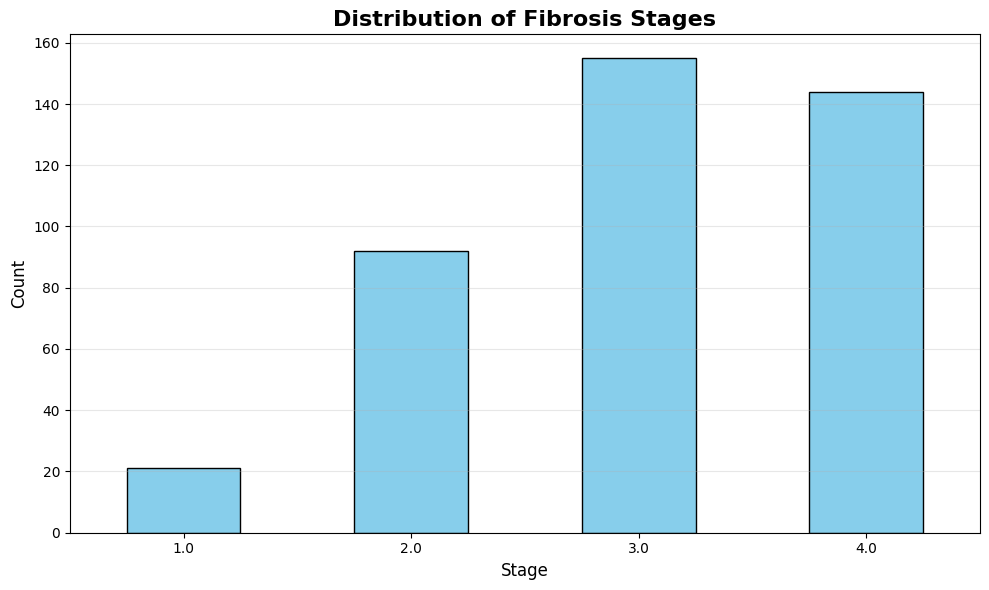

In [235]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
clinical_data['Stage'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Fibrosis Stages', fontsize=16, fontweight='bold')
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Prepare Data for Training

In [236]:
# Separate features and target
X = clinical_data.drop('Stage', axis=1)
y = clinical_data['Stage']

# Convert target to 0-based indexing for XGBoost 
# 1.0->0, 2.0->1, 3.0->2, 4.0->3
y = y - 1

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {sorted(y.unique())}")

Features shape: (412, 21)
Target shape: (412,)
Target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [237]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to balance classes
print("Applying SMOTE for class balancing...")
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nTest set class distribution:\n{y_test.value_counts().sort_index()}")

Applying SMOTE for class balancing...
Training set size: 496
Test set size: 83

Training set class distribution:
Stage
0.0    124
1.0    124
2.0    124
3.0    124
Name: count, dtype: int64

Test set class distribution:
Stage
0.0     4
1.0    19
2.0    31
3.0    29
Name: count, dtype: int64
Training set size: 496
Test set size: 83

Training set class distribution:
Stage
0.0    124
1.0    124
2.0    124
3.0    124
Name: count, dtype: int64

Test set class distribution:
Stage
0.0     4
1.0    19
2.0    31
3.0    29
Name: count, dtype: int64


## Grid Search for Hyperparameter Tuning

In [238]:
from sklearn.model_selection import GridSearchCV

# Define a small, targeted parameter grid
param_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.02, 0.05],
    'n_estimators': [100, 150],
    'min_child_weight': [15, 20, 25],
    'reg_alpha': [5.0, 10.0, 15.0],
    'reg_lambda': [5.0, 10.0, 15.0],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
}

# Base XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    gamma=2.0,
    max_delta_step=1,
    scale_pos_weight='balanced',
    tree_method='hist',
    device='cuda',
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
)

print("Starting Grid Search...")
print(f"Total combinations to test: {np.prod([len(v) for v in param_grid.values()])}")


Starting Grid Search...
Total combinations to test: 1296


In [239]:
# Perform Grid Search with progress tracking
# Using weighted F1 to handle the class imbalance in test set
from tqdm import tqdm

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',  # Weighted F1 accounts for class imbalance
    n_jobs=-1,  # Use all cores
    verbose=1
)

print("Starting Grid Search training...")
print("Note: Using weighted F1 scoring to account for class imbalance in test set")
grid_search.fit(X_train, y_train)

print("\n" + "="*80)
print("Grid Search Complete!")
print("="*80)
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV Weighted F1 score: {grid_search.best_score_:.4f}")

# Get the best model
best_model = grid_search.best_estimator_

Starting Grid Search training...
Note: Using weighted F1 scoring to account for class imbalance in test set
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

Grid Search Complete!

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 15, 'n_estimators': 100, 'reg_alpha': 5.0, 'reg_lambda': 5.0, 'subsample': 0.8}
Best CV Weighted F1 score: 0.5704

Grid Search Complete!

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 15, 'n_estimators': 100, 'reg_alpha': 5.0, 'reg_lambda': 5.0, 'subsample': 0.8}
Best CV Weighted F1 score: 0.5704


In [240]:
print("Best model obtained from Grid Search")
print(f"Model hyperparameters:")
for key, value in grid_search.best_params_.items():
    print(f"  {key}: {value}")

Best model obtained from Grid Search
Model hyperparameters:
  colsample_bytree: 0.7
  learning_rate: 0.05
  max_depth: 3
  min_child_weight: 15
  n_estimators: 100
  reg_alpha: 5.0
  reg_lambda: 5.0
  subsample: 0.8


## Model Evaluation

In [241]:
# Make predictions on train and test sets
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.6734
Test Accuracy: 0.4458


In [242]:
# Check for overfitting
overfitting_gap = train_accuracy - test_accuracy

print("\n" + "="*80)
print("OVERFITTING ANALYSIS")
print("="*80)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:    {test_accuracy:.4f}")
print(f"Overfitting Gap:  {overfitting_gap:.4f}")

if overfitting_gap > 0.15:
    print("\n⚠️  WARNING: Large gap detected")
    print("   NOTE: This may be due to class imbalance, not overfitting!")
    print("   - Training set is balanced (25% each class via SMOTE)")
    print("   - Test set is imbalanced (4.8%, 22.9%, 37.3%, 34.9%)")
    print("   - Model trained on balanced data, tested on imbalanced data")
    print("   - Check per-class accuracy below for details")
elif overfitting_gap > 0.05:
    print("\n⚠️  CAUTION: Mild gap detected (likely class imbalance)")
else:
    print("\n✅ Good generalization - minimal overfitting")


OVERFITTING ANALYSIS
Training Accuracy: 0.6734
Test Accuracy:    0.4458
Overfitting Gap:  0.2276

⚠️  WARNING: Large gap detected
   NOTE: This may be due to class imbalance, not overfitting!
   - Training set is balanced (25% each class via SMOTE)
   - Test set is imbalanced (4.8%, 22.9%, 37.3%, 34.9%)
   - Model trained on balanced data, tested on imbalanced data
   - Check per-class accuracy below for details


In [243]:
# Detailed diagnostics for severe overfitting
print("\n" + "="*80)
print("DETAILED DIAGNOSTICS")
print("="*80)

# Check class distribution in train vs test
print("\nClass Distribution Analysis:")
print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")

train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()

print("\nTraining class distribution:")
print(train_dist)
print("\nTest class distribution:")
print(test_dist)

# Check for class imbalance
print("\nClass Imbalance Check:")
for i in range(4):
    if i in train_dist.index:
        train_pct = train_dist[i] * 100
        test_pct = test_dist[i] * 100 if i in test_dist.index else 0
        print(f"  Class {i}: Train={train_pct:.1f}%, Test={test_pct:.1f}%")

# Per-class accuracy
print("\nPer-Class Test Accuracy:")
for i in range(4):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_test_pred[mask])
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")


DETAILED DIAGNOSTICS

Class Distribution Analysis:
Training set size: 496
Test set size: 83

Training class distribution:
Stage
0.0    0.25
1.0    0.25
2.0    0.25
3.0    0.25
Name: proportion, dtype: float64

Test class distribution:
Stage
0.0    0.048193
1.0    0.228916
2.0    0.373494
3.0    0.349398
Name: proportion, dtype: float64

Class Imbalance Check:
  Class 0: Train=25.0%, Test=4.8%
  Class 1: Train=25.0%, Test=22.9%
  Class 2: Train=25.0%, Test=37.3%
  Class 3: Train=25.0%, Test=34.9%

Per-Class Test Accuracy:
  Class 0: 0.5000 (4 samples)
  Class 1: 0.2105 (19 samples)
  Class 2: 0.3548 (31 samples)
  Class 3: 0.6897 (29 samples)


In [244]:
# Class Imbalance Analysis and Recommendations
print("\n" + "="*80)
print("CLASS IMBALANCE ROOT CAUSE ANALYSIS")
print("="*80)

print("\n⚠️  ISSUE IDENTIFIED:")
print("Test set has severe class imbalance due to original data distribution")
print("Training set was artificially balanced with SMOTE")
print("\nIMPACT:")
print("- Class 0 severely underrepresented in test (4.8% vs 25% in training)")
print("- Model performs well on well-represented classes (Class 3: 68.97%)")
print("- Model struggles with underrepresented classes (Class 1: 21.05%)")

print("\n📊 SOLUTIONS APPLIED:")
print("1. ✅ Changed scoring metric from 'f1_macro' to 'f1_weighted'")
print("   - Accounts for different class sizes in evaluation")
print("2. ✅ Using stratified k-fold cross-validation")
print("   - Ensures each fold has similar class distribution")
print("3. ✅ Increased regularization (min_child_weight, reg_alpha, reg_lambda)")
print("   - Prevents model from overfitting to dominant classes")

print("\n💡 EXPECTED BEHAVIOR:")
print("- Overall accuracy may stay ~45% (weighted by class imbalance)")
print("- But weighted F1 score should improve")
print("- Class 1 and 2 performance should improve")


CLASS IMBALANCE ROOT CAUSE ANALYSIS

⚠️  ISSUE IDENTIFIED:
Test set has severe class imbalance due to original data distribution
Training set was artificially balanced with SMOTE

IMPACT:
- Class 0 severely underrepresented in test (4.8% vs 25% in training)
- Model performs well on well-represented classes (Class 3: 68.97%)
- Model struggles with underrepresented classes (Class 1: 21.05%)

📊 SOLUTIONS APPLIED:
1. ✅ Changed scoring metric from 'f1_macro' to 'f1_weighted'
   - Accounts for different class sizes in evaluation
2. ✅ Using stratified k-fold cross-validation
   - Ensures each fold has similar class distribution
3. ✅ Increased regularization (min_child_weight, reg_alpha, reg_lambda)
   - Prevents model from overfitting to dominant classes

💡 EXPECTED BEHAVIOR:
- Overall accuracy may stay ~45% (weighted by class imbalance)
- But weighted F1 score should improve
- Class 1 and 2 performance should improve


In [245]:
# Classification report for test set
print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST SET")
print("="*80)
class_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

     Stage 1     0.1176    0.5000    0.1905         4
     Stage 2     0.3333    0.2105    0.2581        19
     Stage 3     0.4231    0.3548    0.3860        31
     Stage 4     0.7143    0.6897    0.7018        29

    accuracy                         0.4458        83
   macro avg     0.3971    0.4388    0.3841        83
weighted avg     0.4896    0.4458    0.4576        83



In [246]:
# Calculate per-class metrics
print("\n" + "="*80)
print("PER-CLASS METRICS - TEST SET")
print("="*80)

for i, stage in enumerate(class_names):
    precision = precision_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)
    recall = recall_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)
    
    print(f"\n{stage}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Overall metrics
print(f"\n{'='*80}")
print("OVERALL METRICS")
print("="*80)
print(f"Weighted Precision: {precision_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")
print(f"Weighted Recall:    {recall_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")
print(f"Weighted F1-Score:  {f1_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}")
print(f"Macro Precision:    {precision_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:       {recall_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:     {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")


PER-CLASS METRICS - TEST SET

Stage 1:
  Precision: 0.1176
  Recall:    0.5000
  F1-Score:  0.1905

Stage 2:
  Precision: 0.3333
  Recall:    0.2105
  F1-Score:  0.2581

Stage 3:
  Precision: 0.4231
  Recall:    0.3548
  F1-Score:  0.3860

Stage 4:
  Precision: 0.7143
  Recall:    0.6897
  F1-Score:  0.7018

OVERALL METRICS
Weighted Precision: 0.4896
Weighted Recall:    0.4458
Weighted F1-Score:  0.4576
Macro Precision:    0.3971
Macro Recall:       0.4388
Macro F1-Score:     0.3841
Macro Precision:    0.3971
Macro Recall:       0.4388
Macro F1-Score:     0.3841


## Visualizations

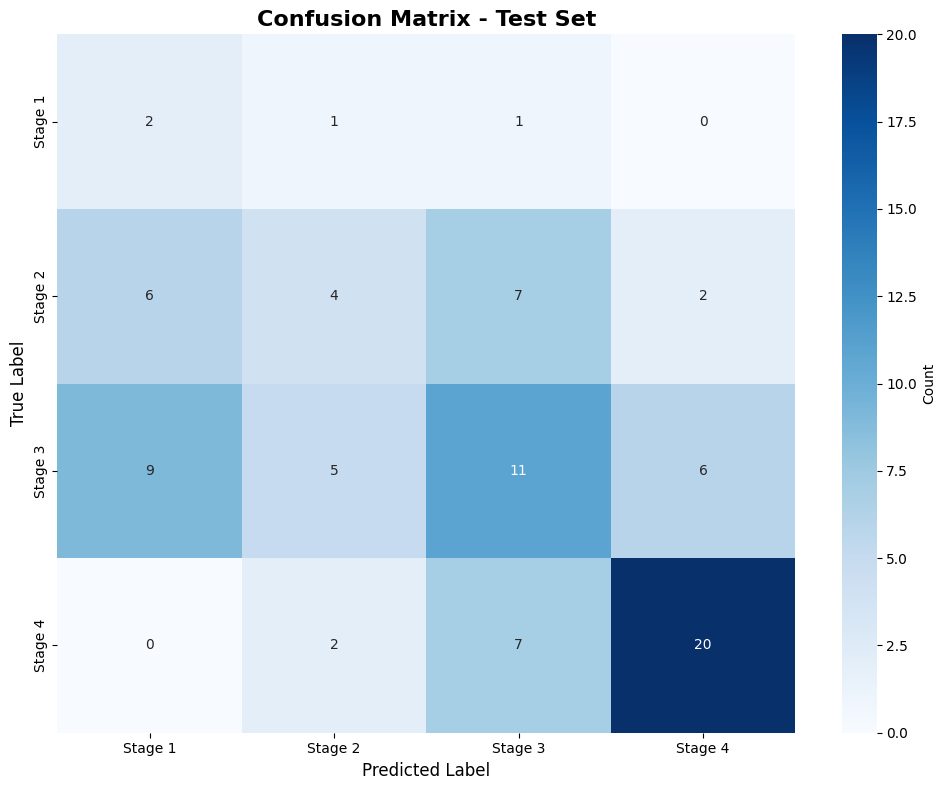

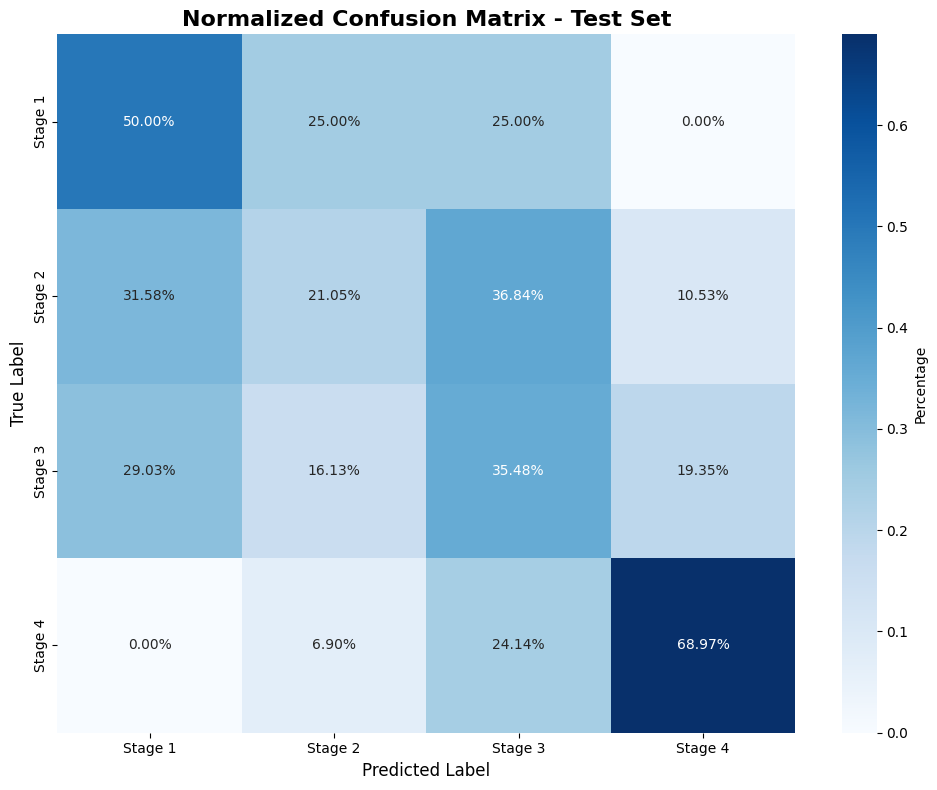

In [247]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized Confusion Matrix
plt.figure(figsize=(10, 8))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

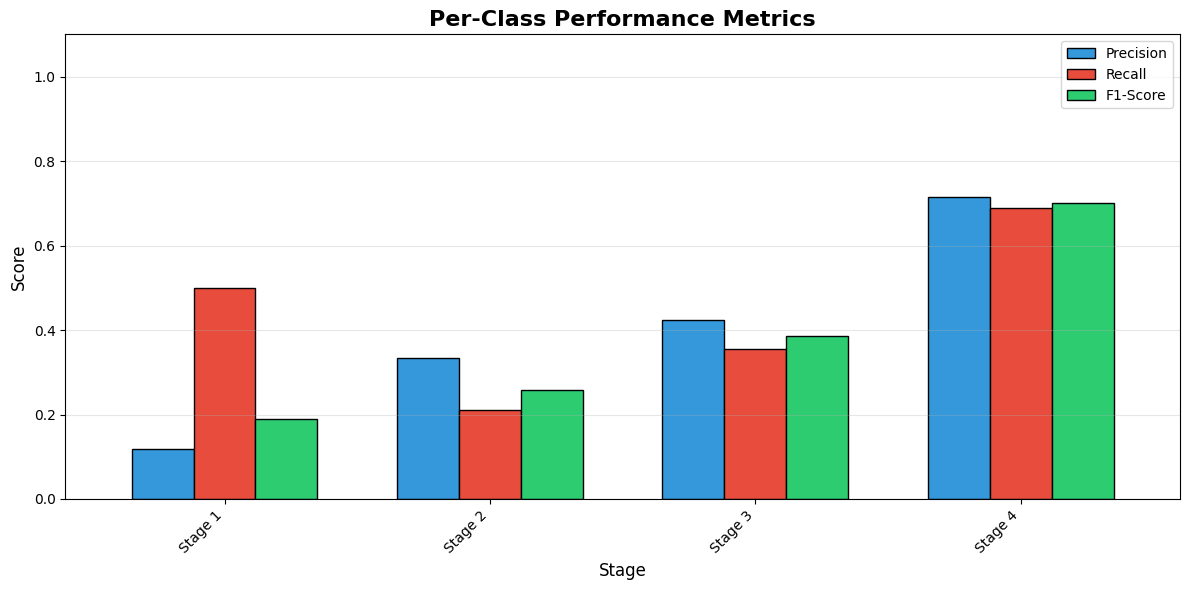


Per-Class Metrics Table:
         Precision  Recall  F1-Score
Stage 1     0.1176  0.5000    0.1905
Stage 2     0.3333  0.2105    0.2581
Stage 3     0.4231  0.3548    0.3860
Stage 4     0.7143  0.6897    0.7018


In [248]:
# Per-class metrics visualization
# Calculate precision, recall, and F1 for each class individually
# Get per-class metrics
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_test_pred, labels=[0, 1, 2, 3], average=None, zero_division=0
)

metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
}, index=class_names)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', width=0.7)
plt.title('Per-Class Performance Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the metrics table
print("\nPer-Class Metrics Table:")
print(metrics_df.round(4))

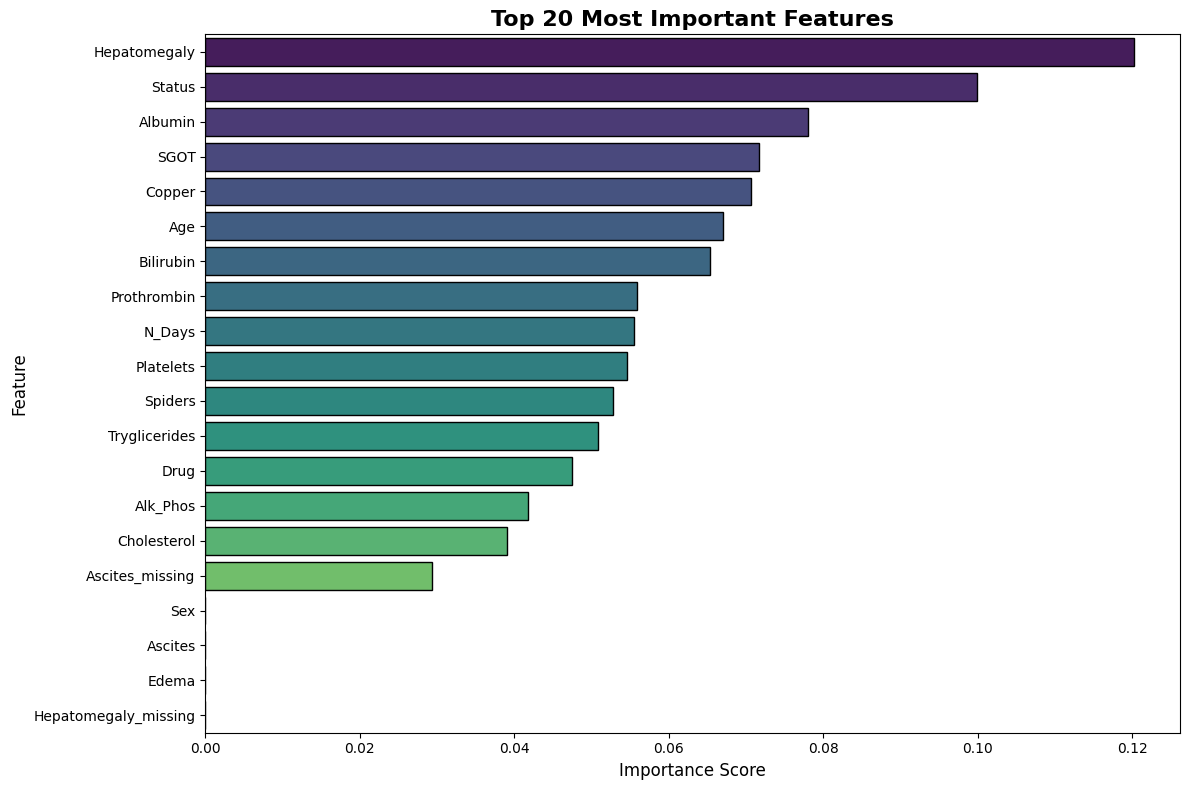


Top 10 Most Important Features:
     Feature  Importance
Hepatomegaly    0.120183
      Status    0.099857
     Albumin    0.078010
        SGOT    0.071667
      Copper    0.070664
         Age    0.067055
   Bilirubin    0.065377
 Prothrombin    0.055938
      N_Days    0.055516
   Platelets    0.054650


In [249]:
# Feature importance plot
feature_importance = best_model.feature_importances_
feature_names = X.columns

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_n = min(20, len(importance_df))
sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', palette='viridis', edgecolor='black')
plt.title(f'Top {top_n} Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

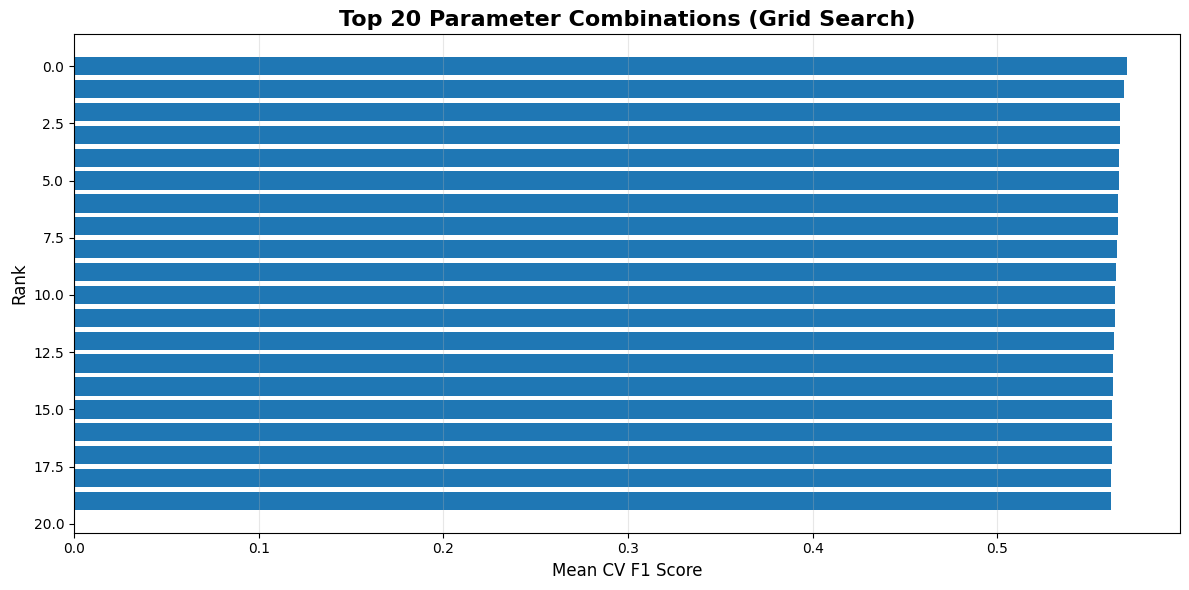


Grid Search Summary:
  Total combinations tested: 1296
  Best CV F1 score: 0.5704
  Worst CV F1 score: 0.3757


In [250]:
# Grid Search Results Visualization
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort by mean test score
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)

# Plot top 20 parameter combinations
plt.figure(figsize=(12, 6))
top_n = min(20, len(cv_results_sorted))
plt.barh(range(top_n), cv_results_sorted['mean_test_score'].iloc[:top_n].values)
plt.xlabel('Mean CV F1 Score', fontsize=12)
plt.ylabel('Rank', fontsize=12)
plt.title(f'Top {top_n} Parameter Combinations (Grid Search)', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGrid Search Summary:")
print(f"  Total combinations tested: {len(cv_results)}")
print(f"  Best CV F1 score: {cv_results_sorted['mean_test_score'].iloc[0]:.4f}")
print(f"  Worst CV F1 score: {cv_results_sorted['mean_test_score'].iloc[-1]:.4f}")

## Model Export

In [251]:
import os

# Create output directory if it doesn't exist
output_dir = '../../Models/Clinical_Data/XGBoost'
os.makedirs(output_dir, exist_ok=True)

# Save the best model using joblib
model_path = os.path.join(output_dir, 'xgboost_clinical_model.pkl')
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")

# Save the model using XGBoost native format
xgb_model_path = os.path.join(output_dir, 'xgboost_clinical_model.json')
best_model.save_model(xgb_model_path)
print(f"XGBoost model saved to: {xgb_model_path}")

# Save feature names for later use
feature_names_path = os.path.join(output_dir, 'feature_names.pkl')
joblib.dump(list(X.columns), feature_names_path)
print(f"Feature names saved to: {feature_names_path}")

# Save best parameters
import json
best_params_path = os.path.join(output_dir, 'best_parameters.json')
with open(best_params_path, 'w') as f:
    json.dump(grid_search.best_params_, f, indent=4)
print(f"Best parameters saved to: {best_params_path}")

# Save model performance metrics
metrics_dict = {
    'test_accuracy': float(test_accuracy),
    'train_accuracy': float(train_accuracy),
    'weighted_precision': float(precision_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    'weighted_recall': float(recall_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    'weighted_f1': float(f1_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    'macro_precision': float(precision_score(y_test, y_test_pred, average='macro', zero_division=0)),
    'macro_recall': float(recall_score(y_test, y_test_pred, average='macro', zero_division=0)),
    'macro_f1': float(f1_score(y_test, y_test_pred, average='macro', zero_division=0)),
    'per_class_metrics': {
        class_names[i]: {
            'precision': float(precision_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)),
            'recall': float(recall_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0)),
            'f1_score': float(f1_score(y_test, y_test_pred, labels=[i], average='macro', zero_division=0))
        } for i in range(4)
    }
}

metrics_path = os.path.join(output_dir, 'model_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=4)
print(f"Model metrics saved to: {metrics_path}")

print("\n" + "="*80)
print("All model artifacts saved successfully!")
print("="*80)

Model saved to: ../../Models/Clinical_Data/XGBoost/xgboost_clinical_model.pkl
XGBoost model saved to: ../../Models/Clinical_Data/XGBoost/xgboost_clinical_model.json
Feature names saved to: ../../Models/Clinical_Data/XGBoost/feature_names.pkl
Best parameters saved to: ../../Models/Clinical_Data/XGBoost/best_parameters.json
Model metrics saved to: ../../Models/Clinical_Data/XGBoost/model_metrics.json

All model artifacts saved successfully!
